# 🧪 Fine-Tuning com LoRA — Modelo Seq2Seq 1
## `unicamp-dl/ptt5-base-portuguese-vocab`

Este notebook aplica **LoRA (Low-Rank Adaptation)** ao modelo `ptt5-base-portuguese-vocab`,
um T5-base adaptado nativamente para o português brasileiro pela Unicamp.

### Por que este modelo?
- O **T5 (Text-to-Text Transfer Transformer)** trata todas as tarefas de NLP como
  problemas de texto-para-texto, tornando-o naturalmente adequado para Q&A.
- O `ptt5-base-portuguese-vocab` é uma adaptação do T5-base original com
  **vocabulário reconstruído para português**, reduzindo a fragmentação de tokens
  em palavras lusófonas (ex.: 'manutenção' vira 1 token, não 4).
- Foi pré-treinado sobre o corpus `brWaC` (Brazilian Web as Corpus), garantindo
  representações semânticas específicas do português brasileiro.

### Diferença fundamental: Seq2Seq vs Causal
| Aspecto | Modelos Causais (GPT-2, BLOOM) | Seq2Seq (T5, mT5) |
|---|---|---|
| Arquitetura | Decoder-only | Encoder-Decoder |
| Formato de entrada | `Instruction: ...\nOutput: ...` (texto único) | Instrução no encoder, resposta no decoder |
| Mascaramento de labels | Manual (−100 na instrução) | **Automático** — encoder e decoder são separados |
| Geração | Continua o texto do prompt | Gera sequência independente a partir do encoder |
| Collator | `DataCollatorForLanguageModeling` | `DataCollatorForSeq2Seq` |

### Vantagem crítica do Seq2Seq para instruction tuning
Em modelos causais, o modelo precisa aprender a **não repetir** a instrução
ao gerar a resposta. Em Seq2Seq, a instrução vai para o encoder e a resposta
é gerada pelo decoder — **sem risco de mistura**. Isso torna o T5 arquiteturalmente
mais adequado para tarefas de Q&A com poucos dados.

## 📦 1. Instalação das dependências

In [ ]:
!pip install -q transformers datasets peft accelerate sentencepiece
!pip uninstall -y torchao 2>/dev/null || true

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


## 🔗 2. Montar o Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📥 3. Importações

Note as importações específicas para Seq2Seq:
- `AutoModelForSeq2SeqLM` em vez de `AutoModelForCausalLM`
- `DataCollatorForSeq2Seq` em vez de `DataCollatorForLanguageModeling`
- `Seq2SeqTrainer` e `Seq2SeqTrainingArguments` com suporte a geração durante avaliação

In [ ]:
import torch
import json
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (
    AutoModelForSeq2SeqLM,   # Seq2Seq — diferente dos modelos causais
    AutoTokenizer,
    DataCollatorForSeq2Seq,  # Seq2Seq — diferente dos modelos causais
    Seq2SeqTrainer,          # Seq2Seq — suporte a geração no eval
    Seq2SeqTrainingArguments # Seq2Seq — inclui predict_with_generate
)
from peft import LoraConfig, get_peft_model, TaskType

print(f"PyTorch: {torch.__version__}")
print(f"GPU disponível: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.11.0+cu128
GPU disponível: True
GPU: Tesla T4
VRAM: 15.6 GB


## 📂 4. Carregar e Preparar o Dataset

### Formato Seq2Seq — diferença fundamental dos modelos causais

Em modelos causais, combinávamos instrução e resposta em **um único texto**:
```
Instruction: <pergunta>\nOutput: <resposta>
```

Em Seq2Seq, mantemos instrução e resposta **separadas**:
- **Input (encoder):** `Instruction: <pergunta>`
- **Target (decoder/labels):** `<resposta>`

O mascaramento de labels **não é necessário** — o encoder processa a instrução
e o decoder gera apenas a resposta. São componentes separados do modelo.

In [ ]:
# ── Configuração ──────────────────────────────────────────────────────────────
DATASET_PATH    = "/content/drive/MyDrive/dataset_gerado_v3 (1).jsonl"  # ajuste se necessário
MODEL_SAVE_PATH = "/content/drive/MyDrive/lora_seq2seq_model_1"
MAX_INPUT_LENGTH  = 128   # comprimento máximo da instrução (encoder)
MAX_TARGET_LENGTH = 128   # comprimento máximo da resposta (decoder)
# ──────────────────────────────────────────────────────────────────────────────

# Carrega o dataset
dataset = load_dataset("json", data_files=DATASET_PATH)

# Divide em treino (80%) e teste (20%) — mesma seed dos modelos causais
dataset = dataset["train"].train_test_split(test_size=0.2, seed=42)

print(dataset)
print("\nExemplo do dataset:")
print(f"  Instruction: {dataset['train'][0]['Instruction']}")
print(f"  Output:      {dataset['train'][0]['Output']}")

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Instruction', 'Output'],
        num_rows: 121
    })
    test: Dataset({
        features: ['Instruction', 'Output'],
        num_rows: 31
    })
})

Exemplo do dataset:
  Instruction: Como garantir um desempenho máximo e economia em operações ao usar este equipamento?
  Output:      Para maximizar o desempenho e a economia de operações, é crucial seguir todas as recomendações de segurança, cuidados e manutenção. Isso inclui regularmente ajustar e inspecionar rapidamente os componentes de disco, manter os parafusos afrouxados e monitorar a velocidade do trator conforme solicitado.


## 🤖 5. Carregar o Modelo e o Tokenizador

### Particularidades do ptt5-base-portuguese-vocab

- **Vocabulário**: 32.000 tokens otimizados para português (vs 32.100 do T5 original em inglês)
- **SentencePiece**: usa tokenização por subpalavras, eficiente para português
- **Tamanho**: ~248M parâmetros (encoder + decoder)
- **Sem pad_token problem**: T5 já define `pad_token_id=0` nativamente

In [ ]:
model_name = "unicamp-dl/ptt5-base-portuguese-vocab"

print(f"Carregando tokenizador: {model_name}")
tokenizer = AutoTokenizer.from_pretrained(model_name)

print(f"pad_token:  '{tokenizer.pad_token}' (id={tokenizer.pad_token_id})")
print(f"eos_token:  '{tokenizer.eos_token}' (id={tokenizer.eos_token_id})")
print(f"Vocabulário: {tokenizer.vocab_size:,} tokens")

print(f"\nCarregando modelo base: {model_name}")
base_model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name,
    torch_dtype=torch.float32
)

total_params = sum(p.numel() for p in base_model.parameters())
print(f"\nModelo carregado: {model_name}")
print(f"Total de parâmetros: {total_params:,}")

# Demonstra eficiência do vocabulário português
teste_pt = "manutenção e lubrificação das graxeiras do equipamento"
tokens_pt = tokenizer.tokenize(teste_pt)
print(f"\nDemonstração de tokenização em PT:")
print(f"  Texto: '{teste_pt}'")
print(f"  Tokens ({len(tokens_pt)}): {tokens_pt}")

Carregando tokenizador: unicamp-dl/ptt5-base-portuguese-vocab


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/456 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/756k [00:00<?, ?B/s]

pad_token:  '<pad>' (id=0)
eos_token:  '</s>' (id=1)
Vocabulário: 32,100 tokens

Carregando modelo base: unicamp-dl/ptt5-base-portuguese-vocab


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]


Modelo carregado: unicamp-dl/ptt5-base-portuguese-vocab
Total de parâmetros: 222,903,552

Demonstração de tokenização em PT:
  Texto: 'manutenção e lubrificação das graxeiras do equipamento'
  Tokens (11): ['▁manutenção', '▁e', '▁lu', 'br', 'ificação', '▁das', '▁gra', 'x', 'eiras', '▁do', '▁equipamento']


## 🧪 6. Inferência ANTES do Fine-Tuning (Modelo Base)

### Como funciona a geração em Seq2Seq
Diferente dos modelos causais, passamos **apenas a instrução** para o modelo.
O encoder processa a instrução e o decoder gera a resposta do zero —
sem precisar extrair substrings ou dividir por `Output:`.

In [ ]:
def generate_response(model, tokenizer, instruction, max_new_tokens=128):
    """
    Gera resposta com modelo Seq2Seq.
    A instrução vai para o encoder; o decoder gera a resposta do zero.
    Não é necessário extrair substrings — a saída já é apenas a resposta.
    """
    # Prefixo T5 para task de geração de texto
    # Para ptt5, passamos diretamente a instrução formatada
    input_text = f"Instruction: {instruction}"

    device = next(model.parameters()).device
    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        max_length=MAX_INPUT_LENGTH,
        truncation=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        output_ids = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=max_new_tokens,
            num_beams=4,          # beam search — padrão para Seq2Seq
            early_stopping=True,
            no_repeat_ngram_size=3
        )

    # Decodifica apenas os tokens gerados (não o input)
    resposta = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return resposta


# Mesma pergunta dos modelos causais — comparação direta entre os 4 modelos
test_instruction = "Qual é a recomendação para transportar o equipamento por longas distâncias?"

print("=" * 60)
print("ANTES DO FINE-TUNING (ptt5-base base)")
print("=" * 60)
print(f"Instrução: {test_instruction}")
print(f"Resposta:  {generate_response(base_model, tokenizer, test_instruction)}")

ANTES DO FINE-TUNING (ptt5-base base)
Instrução: Qual é a recomendação para transportar o equipamento por longas distâncias?
Resposta:  Instruction: Qual é a recomendação para transportar o equipamento por longas distâncias?


## ✂️ 7. Tokenização para Seq2Seq

### Por que não precisamos de mascaramento manual

Em modelos causais, instrução e resposta ficam no mesmo tensor — por isso
precisávamos de `-100` para mascarar a instrução nos labels.

Em Seq2Seq:
- `input_ids` → instrução processada pelo **encoder**
- `labels` → resposta gerada pelo **decoder**

São tensores diferentes. O loss é calculado **somente sobre os `labels`**
por design da arquitetura — sem código adicional necessário.

O `DataCollatorForSeq2Seq` ainda aplica `-100` automaticamente nas posições
de padding dos labels, garantindo que o padding não contribua para o loss.

In [ ]:
def tokenize_seq2seq(examples):
    """
    Tokeniza para Seq2Seq:
    - input_ids: instrução (vai para o encoder)
    - labels: resposta (vai para o decoder como target)

    Não é necessário mascaramento manual: encoder e decoder
    são componentes separados na arquitetura T5.
    """
    # Prepara os inputs (instruções)
    inputs = [f"Instruction: {instr}" for instr in examples["Instruction"]]

    # Tokeniza instruções (encoder input)
    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LENGTH,
        padding="max_length",
        truncation=True
    )

    # Tokeniza respostas (decoder target / labels)
    # A função `as_target_tokenizer()` não é necessária para T5Tokenizer.
    # O tokenizer pode processar diretamente os outputs.
    labels = tokenizer(
        examples["Output"],
        max_length=MAX_TARGET_LENGTH,
        padding="max_length",
        truncation=True
    )

    # O DataCollatorForSeq2Seq substituirá os tokens de padding (-100)
    # nos labels automaticamente durante o collation
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


print("Tokenizando dataset para Seq2Seq...")
tokenized_datasets = dataset.map(
    tokenize_seq2seq,
    batched=True,
    remove_columns=dataset["train"].column_names
)

print("Dataset tokenizado:", tokenized_datasets)

# Verificação: mostra o que vai para encoder vs decoder
sample = tokenized_datasets["train"][0]
print(f"\nVerificação no 1º exemplo:")
print(f"  input_ids (encoder) — {len(sample['input_ids'])} tokens")
print(f"  Decodificado: {tokenizer.decode(sample['input_ids'], skip_special_tokens=True)[:80]}...")
print(f"\n  labels (decoder target) — {len(sample['labels'])} tokens")
# Filtra padding tokens antes de decodificar para visualização
valid_labels = [l for l in sample['labels'] if l != tokenizer.pad_token_id]
print(f"  Decodificado: {tokenizer.decode(valid_labels, skip_special_tokens=True)}")

Tokenizando dataset para Seq2Seq...


Map:   0%|          | 0/121 [00:00<?, ? examples/s]

Map:   0%|          | 0/31 [00:00<?, ? examples/s]

Dataset tokenizado: DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 121
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 31
    })
})

Verificação no 1º exemplo:
  input_ids (encoder) — 128 tokens
  Decodificado: Instruction: Como garantir um desempenho máximo e economia em operações ao usar ...

  labels (decoder target) — 128 tokens
  Decodificado: Para maximizar o desempenho e a economia de operações, é crucial seguir todas as recomendações de segurança, cuidados e manutenção. Isso inclui regularmente ajustar e inspecionar rapidamente os componentes de disco, manter os parafusos afrouxados e monitorar a velocidade do trator conforme solicitado.


## 🧩 8. Configurar e Injetar LoRA

### Justificativa dos hiperparâmetros

| Parâmetro | Valor | Justificativa |
|---|---|---|
| `r` | 16 | Rank igual ao Causal 1. O T5-base tem ~248M parâmetros (encoder + decoder). Com dataset pequeno (~100 exemplos), r=16 é suficiente para adaptação de domínio sem overfitting. |
| `lora_alpha` | 32 | Escala efetiva α/r = 32/16 = 2.0 — mesma proporção dos outros modelos, comparação controlada. |
| `target_modules` | q, v | **Específico para T5/ptt5**. O T5 decompõe a atenção em projeções separadas `q`, `k`, `v`, `o`. Adaptar `q` e `v` é o padrão recomendado (Hu et al., 2021): `q` controla o que buscar, `v` controla o que extrair. Inclui tanto encoder quanto decoder. |
| `lora_dropout` | 0.05 | Dropout leve como regularizador. Mantido igual aos modelos causais. |
| `task_type` | `SEQ_2_SEQ_LM` | **Diferente dos causais** (`CAUSAL_LM`). Indica ao PEFT que os adaptadores devem ser aplicados tanto no encoder quanto no decoder. |

### Por que `q` e `v` no T5?
A arquitetura T5 usa atenção multi-cabeça com projeções separadas:
- `q` (query): determina **o que o modelo está buscando**
- `k` (key): determina **com o que comparar**  
- `v` (value): determina **o que extrair**
- `o` (output): projeta a saída da atenção

Adaptar `q` e `v` cobre tanto a direção de busca quanto o conteúdo extraído,
sendo suficiente para especialização de domínio com poucos dados.

In [ ]:
# Inspeciona os nomes das camadas de atenção para confirmar target_modules
print("Camadas de atenção no ptt5-base:")
seen = set()
for name, module in base_model.named_modules():
    for key in ["q", "v", "k", "o"]:
        if name.endswith(f".{key}") and name not in seen:
            print(f"  {name} — {type(module).__name__}")
            seen.add(name)
            break

Camadas de atenção no ptt5-base:
  encoder.block.0.layer.0.SelfAttention.q — Linear
  encoder.block.0.layer.0.SelfAttention.k — Linear
  encoder.block.0.layer.0.SelfAttention.v — Linear
  encoder.block.0.layer.0.SelfAttention.o — Linear
  encoder.block.1.layer.0.SelfAttention.q — Linear
  encoder.block.1.layer.0.SelfAttention.k — Linear
  encoder.block.1.layer.0.SelfAttention.v — Linear
  encoder.block.1.layer.0.SelfAttention.o — Linear
  encoder.block.2.layer.0.SelfAttention.q — Linear
  encoder.block.2.layer.0.SelfAttention.k — Linear
  encoder.block.2.layer.0.SelfAttention.v — Linear
  encoder.block.2.layer.0.SelfAttention.o — Linear
  encoder.block.3.layer.0.SelfAttention.q — Linear
  encoder.block.3.layer.0.SelfAttention.k — Linear
  encoder.block.3.layer.0.SelfAttention.v — Linear
  encoder.block.3.layer.0.SelfAttention.o — Linear
  encoder.block.4.layer.0.SelfAttention.q — Linear
  encoder.block.4.layer.0.SelfAttention.k — Linear
  encoder.block.4.layer.0.SelfAttention.v — Linea

In [ ]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    # Módulos de atenção do T5 — separados (diferente do GPT-2 que usa c_attn unificado)
    target_modules=["q", "v"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM,  # SEQ_2_SEQ_LM — diferente de CAUSAL_LM
    inference_mode=False
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

trainable params: 1,769,472 || all params: 224,673,024 || trainable%: 0.7876


## 🧱 9. Data Collator para Seq2Seq

`DataCollatorForSeq2Seq` é específico para arquiteturas encoder-decoder:
- Faz padding dinâmico nos `input_ids` (encoder) e `labels` (decoder) separadamente
- Substitui automaticamente os tokens de padding nos `labels` por `-100`,
  garantindo que o padding não contribua para o loss
- Gera o `decoder_input_ids` deslocando os labels (teacher forcing)

In [ ]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100,  # padding nos labels ignorado no loss
    pad_to_multiple_of=8      # alinha ao múltiplo de 8 para eficiência em GPU
)

## ⚙️ 10. Argumentos de Treinamento

Usamos `Seq2SeqTrainingArguments` que inclui o parâmetro `predict_with_generate`,
permitindo avaliar a qualidade real das respostas geradas durante o treinamento.

### Justificativa dos hiperparâmetros

| Parâmetro | Valor | Justificativa |
|---|---|---|
| `learning_rate` | 3e-4 | Levemente maior que os causais. T5 com LoRA responde bem a LRs entre 1e-4 e 5e-4 — valores da literatura de instruction tuning com PEFT (Chung et al., 2022). |
| `num_train_epochs` | 10 | Mesmas épocas dos modelos causais para comparação controlada. |
| `per_device_train_batch_size` | 4 | T5-base (~248M params) cabe confortavelmente em batch 4 na T4. |
| `predict_with_generate` | True | **Específico para Seq2Seq**: avalia gerando respostas reais em vez de usar logits, o que mede melhor a qualidade de saída. |
| `generation_max_length` | 128 | Comprimento máximo das respostas geradas durante avaliação. |

In [ ]:
training_args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/results_seq2seq_1",
    eval_strategy="steps",
    eval_steps=50,
    learning_rate=3e-4,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=10,
    weight_decay=0.01,
    logging_steps=10,
    save_strategy="steps",
    save_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    predict_with_generate=True,      # Seq2Seq: gera respostas durante avaliação
    generation_max_length=MAX_TARGET_LENGTH,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

## 🏋️ 11. Treinar o Modelo

In [ ]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    # tokenizer=tokenizer, # Remove este argumento, pois data_collator já o possui
    data_collator=data_collator,
)

print("Iniciando treinamento...")
train_result = trainer.train()
print("\nTreinamento concluído!")
print(f"Loss final de treino: {train_result.training_loss:.4f}")

Iniciando treinamento...


Step,Training Loss,Validation Loss
50,2.350353,1.194020
100,1.026086,1.014968
150,1.055136,0.956010
200,0.972154,0.929850
250,1.072270,0.911726
300,1.028367,0.902037
310,1.020000,0.901791



Treinamento concluído!
Loss final de treino: 3.4260


## 📊 12. Gráfico de Loss por Step

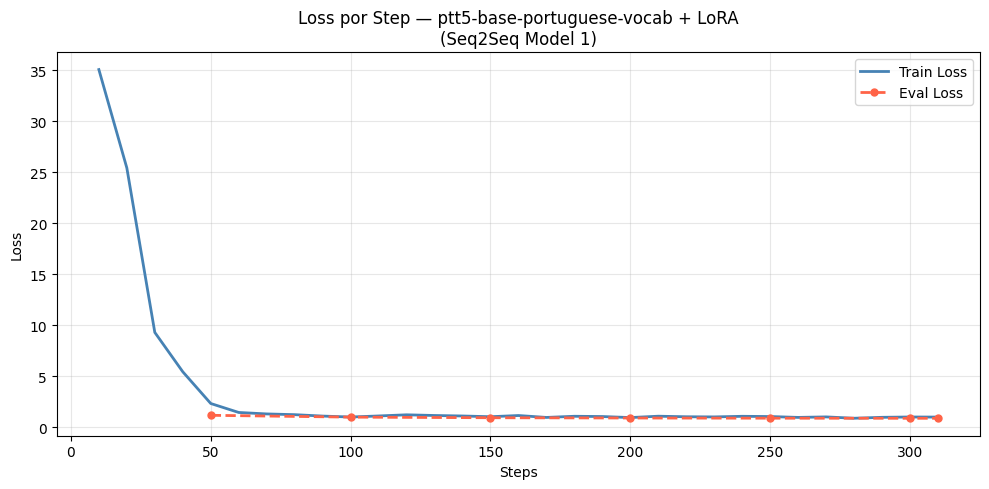

Gráfico salvo em: /content/drive/MyDrive/loss_seq2seq_model_1.png


In [ ]:
log_history = trainer.state.log_history

train_steps, train_losses = [], []
eval_steps, eval_losses   = [], []

for entry in log_history:
    if "loss" in entry and "eval_loss" not in entry:
        train_steps.append(entry["step"])
        train_losses.append(entry["loss"])
    if "eval_loss" in entry:
        eval_steps.append(entry["step"])
        eval_losses.append(entry["eval_loss"])

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_losses, label="Train Loss", color="steelblue", linewidth=2)
plt.plot(eval_steps, eval_losses, label="Eval Loss", color="tomato",
         linewidth=2, linestyle="--", marker="o", markersize=5)
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Loss por Step — ptt5-base-portuguese-vocab + LoRA\n(Seq2Seq Model 1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/loss_seq2seq_model_1.png", dpi=150)
plt.show()
print("Gráfico salvo em: /content/drive/MyDrive/loss_seq2seq_model_1.png")

## 💾 13. Salvar o Modelo Ajustado

In [ ]:
model.save_pretrained(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

print(f"Modelo salvo em: {MODEL_SAVE_PATH}")

metadata = {
    "modelo_base": "unicamp-dl/ptt5-base-portuguese-vocab",
    "tipo": "Seq2Seq (Encoder-Decoder)",
    "arquitetura": "T5-base adaptado para português",
    "lora_r": 16,
    "lora_alpha": 32,
    "target_modules": ["q", "v"],
    "task_type": "SEQ_2_SEQ_LM",
    "lora_dropout": 0.05,
    "learning_rate": 3e-4,
    "num_epochs": 10,
    "max_input_length": MAX_INPUT_LENGTH,
    "max_target_length": MAX_TARGET_LENGTH,
    "label_masking": "automático (arquitetura Seq2Seq)",
    "loss_final_treino": round(train_result.training_loss, 4)
}

with open(f"{MODEL_SAVE_PATH}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Metadados salvos.")

Modelo salvo em: /content/drive/MyDrive/lora_seq2seq_model_1
Metadados salvos.


## 🔄 14. Carregar o Modelo Salvo para Inferência

In [ ]:
from peft import PeftModel

# Carrega o modelo base Seq2Seq
base_for_inference = AutoModelForSeq2SeqLM.from_pretrained(
    "unicamp-dl/ptt5-base-portuguese-vocab",
    torch_dtype=torch.float32
)

# Carrega os adaptadores LoRA
finetuned_model = PeftModel.from_pretrained(base_for_inference, MODEL_SAVE_PATH)
finetuned_model.eval()

finetuned_tokenizer = AutoTokenizer.from_pretrained(MODEL_SAVE_PATH)

print("Modelo fine-tunado carregado com sucesso.")

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

Modelo fine-tunado carregado com sucesso.


## 🆚 15. Comparação: Antes vs Depois do Fine-Tuning

Usamos **exatamente a mesma instrução** dos modelos causais para
permitir comparação cruzada entre os 4 modelos no relatório.

In [ ]:
test_instruction = "Qual é a recomendação para transportar o equipamento por longas distâncias?"

resposta_base = generate_response(base_model, tokenizer, test_instruction)
resposta_ft   = generate_response(finetuned_model, finetuned_tokenizer, test_instruction)

print("=" * 60)
print(f"Instrução: {test_instruction}")
print("=" * 60)
print(f"\n[ANTES  - ptt5-base base]:\n{resposta_base}")
print(f"\n[DEPOIS - ptt5-base fine-tunado]:\n{resposta_ft}")
print("\n[REFERÊNCIA do dataset]:")
print("Deve-se utilizar veículo como caminhão, carreta ou prancha.")

Instrução: Qual é a recomendação para transportar o equipamento por longas distâncias?

[ANTES  - ptt5-base base]:
A recomendação é transportar o equipamento por longas distâncias.

[DEPOIS - ptt5-base fine-tunado]:
A recomendação é transportar o equipamento por longas distâncias.

[REFERÊNCIA do dataset]:
Deve-se utilizar veículo como caminhão, carreta ou prancha.


## 🔍 16. Testes Adicionais

Mesmas perguntas dos modelos causais para comparação direta na tabela do relatório.

In [ ]:
perguntas_teste = [
    "Qual é o rendimento horário trabalhando com um equipamento de 24 discos?",
    "Com que frequência as graxeiras devem ser lubrificadas?",
    "Qual é a velocidade de trabalho recomendada para a Grade Hidráulica GH?",
]

print("=" * 60)
print("TESTES ADICIONAIS — Comparação Base vs Fine-Tunado (ptt5)")
print("=" * 60)

for pergunta in perguntas_teste:
    r_base = generate_response(base_model, tokenizer, pergunta)
    r_ft   = generate_response(finetuned_model, finetuned_tokenizer, pergunta)
    print(f"\nPergunta: {pergunta}")
    print(f"  Base:        {r_base[:120]}..." if len(r_base) > 120 else f"  Base:        {r_base}")
    print(f"  Fine-tunado: {r_ft[:120]}..."  if len(r_ft)   > 120 else f"  Fine-tunado: {r_ft}")
    print("-" * 60)

TESTES ADICIONAIS — Comparação Base vs Fine-Tunado (ptt5)

Pergunta: Qual é o rendimento horário trabalhando com um equipamento de 24 discos?
  Base:        O rendimento horário de trabalho é de 24 horas.
  Fine-tunado: O rendimento horário de trabalho é de 24 horas.
------------------------------------------------------------

Pergunta: Com que frequência as graxeiras devem ser lubrificadas?
  Base:        A graxeira deve ser lavada com cuidado e com cuidado.
  Fine-tunado: A graxeira deve ser lavada com cuidado e com cuidado.
------------------------------------------------------------

Pergunta: Qual é a velocidade de trabalho recomendada para a Grade Hidráulica GH?
  Base:        A velocidade de trabalho recomendada para a Grade Hidráulica GH é de 3 km/h.
  Fine-tunado: A velocidade de trabalho recomendada para a Grade Hidráulica GH é de 3 km/h.
------------------------------------------------------------


## 📋 17. Resumo para o Relatório

In [ ]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())

print("=" * 60)
print("RESUMO — Modelo Seq2Seq 1")
print("=" * 60)
print(f"Modelo base:             unicamp-dl/ptt5-base-portuguese-vocab")
print(f"Tipo:                    Seq2Seq (Encoder-Decoder)")
print(f"Parâmetros treináveis:   {trainable:,} ({100*trainable/total:.2f}% do total)")
print(f"Parâmetros totais:       {total:,}")
print(f"LoRA rank (r):           16")
print(f"LoRA alpha:              32  (escala efetiva α/r = 2.0)")
print(f"Target modules:          q, v  (atenção T5 encoder + decoder)")
print(f"Task type:               SEQ_2_SEQ_LM")
print(f"LoRA dropout:            0.05")
print(f"Learning rate:           3e-4")
print(f"Épocas:                  10")
print(f"Max input length:        {MAX_INPUT_LENGTH} tokens")
print(f"Max target length:       {MAX_TARGET_LENGTH} tokens")
print(f"Label masking:           Automático (arquitetura Seq2Seq)")
print(f"Loss final de treino:    {train_result.training_loss:.4f}")
print(f"Modelo salvo em:         {MODEL_SAVE_PATH}")

print("\n" + "=" * 60)
print("COMPARAÇÃO ENTRE OS 4 MODELOS")
print("=" * 60)
header = f"{'Aspecto':<28} {'C1 GPT2-PT':<18} {'C2 BLOOM':<18} {'S1 ptt5':<18} {'S2 mT5'}"
print(header)
print("-" * 90)
print(f"{'Tipo':<28} {'Causal':<18} {'Causal':<18} {'Seq2Seq':<18} {'Seq2Seq'}")
print(f"{'Parâmetros':<28} {'~124M':<18} {'~560M':<18} {'~248M':<18} {'~300M'}")
print(f"{'Língua base':<28} {'PT-BR':<18} {'Multilingual':<18} {'PT-BR':<18} {'Multilingual'}")
print(f"{'LoRA rank':<28} {'16':<18} {'8':<18} {'16':<18} {'16'}")
print(f"{'Target modules':<28} {'c_attn,c_proj':<18} {'qkv,dense':<18} {'q,v':<18} {'q,v'}")
print(f"{'Label masking':<28} {'Manual':<18} {'Manual':<18} {'Automático':<18} {'Automático'}")

RESUMO — Modelo Seq2Seq 1
Modelo base:             unicamp-dl/ptt5-base-portuguese-vocab
Tipo:                    Seq2Seq (Encoder-Decoder)
Parâmetros treináveis:   1,769,472 (0.79% do total)
Parâmetros totais:       224,673,024
LoRA rank (r):           16
LoRA alpha:              32  (escala efetiva α/r = 2.0)
Target modules:          q, v  (atenção T5 encoder + decoder)
Task type:               SEQ_2_SEQ_LM
LoRA dropout:            0.05
Learning rate:           3e-4
Épocas:                  10
Max input length:        128 tokens
Max target length:       128 tokens
Label masking:           Automático (arquitetura Seq2Seq)
Loss final de treino:    3.4260
Modelo salvo em:         /content/drive/MyDrive/lora_seq2seq_model_1

COMPARAÇÃO ENTRE OS 4 MODELOS
Aspecto                      C1 GPT2-PT         C2 BLOOM           S1 ptt5            S2 mT5
------------------------------------------------------------------------------------------
Tipo                         Causal             Causa